In [68]:
from sklearn.datasets import load_breast_cancer

bc= load_breast_cancer()


In [69]:
print(bc.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [70]:
bc.target.shape


(569,)

In [71]:
bc.data.shape

(569, 30)

# Preproccesing


In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(bc.data, bc.target, test_size=0.2)

In [73]:
print(f"Features train shape: {X_train.shape} Labels train shape: {y_train.shape}")
print(f"Features train shape: {X_test.shape} Labels train shape: {y_test.shape}")


Features train shape: (455, 30) Labels train shape: (455,)
Features train shape: (114, 30) Labels train shape: (114,)


In [74]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train_scaled shape:", X_train.shape)
print("X_test_scaled shape:", X_test.shape)
X_test[0]


X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)


array([0.27161721, 0.1376395 , 0.26252505, 0.1478685 , 0.33858658,
       0.19799399, 0.03017807, 0.09562624, 0.29191919, 0.23251896,
       0.02403393, 0.07357231, 0.0274702 , 0.01145162, 0.20127677,
       0.07170968, 0.02160632, 0.19506112, 0.0824281 , 0.02920377,
       0.19815012, 0.14552239, 0.1898999 , 0.09056724, 0.38717559,
       0.13243724, 0.04179712, 0.21797251, 0.1584861 , 0.12021024])

# Classification

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
def evaluate_model(y_train, y_test, y_train_pred, y_test_pred):
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
    print("Train Precision:", precision_score(y_train, y_train_pred))
    print("Test Precision:", precision_score(y_test, y_test_pred))
    print("Train Recall:", recall_score(y_train, y_train_pred))
    print("Test Recall:", recall_score(y_test, y_test_pred))


## 1. Naive Bayes

In [76]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [77]:
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)
print("Gaussian Naive Bayes Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)


Gaussian Naive Bayes Performance:
Train Accuracy: 0.9384615384615385
Test Accuracy: 0.8947368421052632
Train Precision: 0.9523809523809523
Test Precision: 0.8923076923076924
Train Recall: 0.9523809523809523
Test Recall: 0.9206349206349206


## 2.KNN

In [78]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5 , algorithm='kd_tree',leaf_size=28)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'kd_tree'
,leaf_size,28
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [79]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
print("KNN Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

KNN Performance:
Train Accuracy: 0.9846153846153847
Test Accuracy: 0.9210526315789473
Train Precision: 0.979933110367893
Test Precision: 0.8970588235294118
Train Recall: 0.9965986394557823
Test Recall: 0.9682539682539683


## 3.Decision tree

In [80]:
from sklearn.tree import DecisionTreeClassifier
dt= DecisionTreeClassifier(criterion='entropy', max_depth=63, min_samples_split=4) 
dt.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,63
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [81]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)
print("Decision Tree Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

Decision Tree Performance:
Train Accuracy: 0.9978021978021978
Test Accuracy: 0.8859649122807017
Train Precision: 0.9966101694915255
Test Precision: 0.9032258064516129
Train Recall: 1.0
Test Recall: 0.8888888888888888


## 4.Random Forest

In [82]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, max_depth=64, min_samples_split=8)
rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,64
,min_samples_split,8
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
print("Random Forest Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

Random Forest Performance:
Train Accuracy: 0.9956043956043956
Test Accuracy: 0.9473684210526315
Train Precision: 0.9932432432432432
Test Precision: 0.9253731343283582
Train Recall: 1.0
Test Recall: 0.9841269841269841


## 5.SVM

In [84]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [85]:
y_train_pred = svm.predict(X_train)
y_test_pred = svm.predict(X_test)
print("SVM Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

SVM Performance:
Train Accuracy: 0.9934065934065934
Test Accuracy: 0.9210526315789473
Train Precision: 0.98989898989899
Test Precision: 0.921875
Train Recall: 1.0
Test Recall: 0.9365079365079365


## 6. Logistic Regression

In [86]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [87]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)
print("SVM Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

SVM Performance:
Train Accuracy: 0.9736263736263736
Test Accuracy: 0.9298245614035088
Train Precision: 0.9607843137254902
Test Precision: 0.8985507246376812
Train Recall: 1.0
Test Recall: 0.9841269841269841


## 7. ANN

In [88]:
from sklearn.neural_network import MLPClassifier
ann = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500)
ann.fit(X_train, y_train)

,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,None


In [89]:
y_train_pred = ann.predict(X_train)
y_test_pred = ann.predict(X_test)
print("SVM Performance:")
evaluate_model(y_train, y_test, y_train_pred, y_test_pred)

SVM Performance:
Train Accuracy: 0.9956043956043956
Test Accuracy: 0.9298245614035088
Train Precision: 0.9932432432432432
Test Precision: 0.9104477611940298
Train Recall: 1.0
Test Recall: 0.9682539682539683


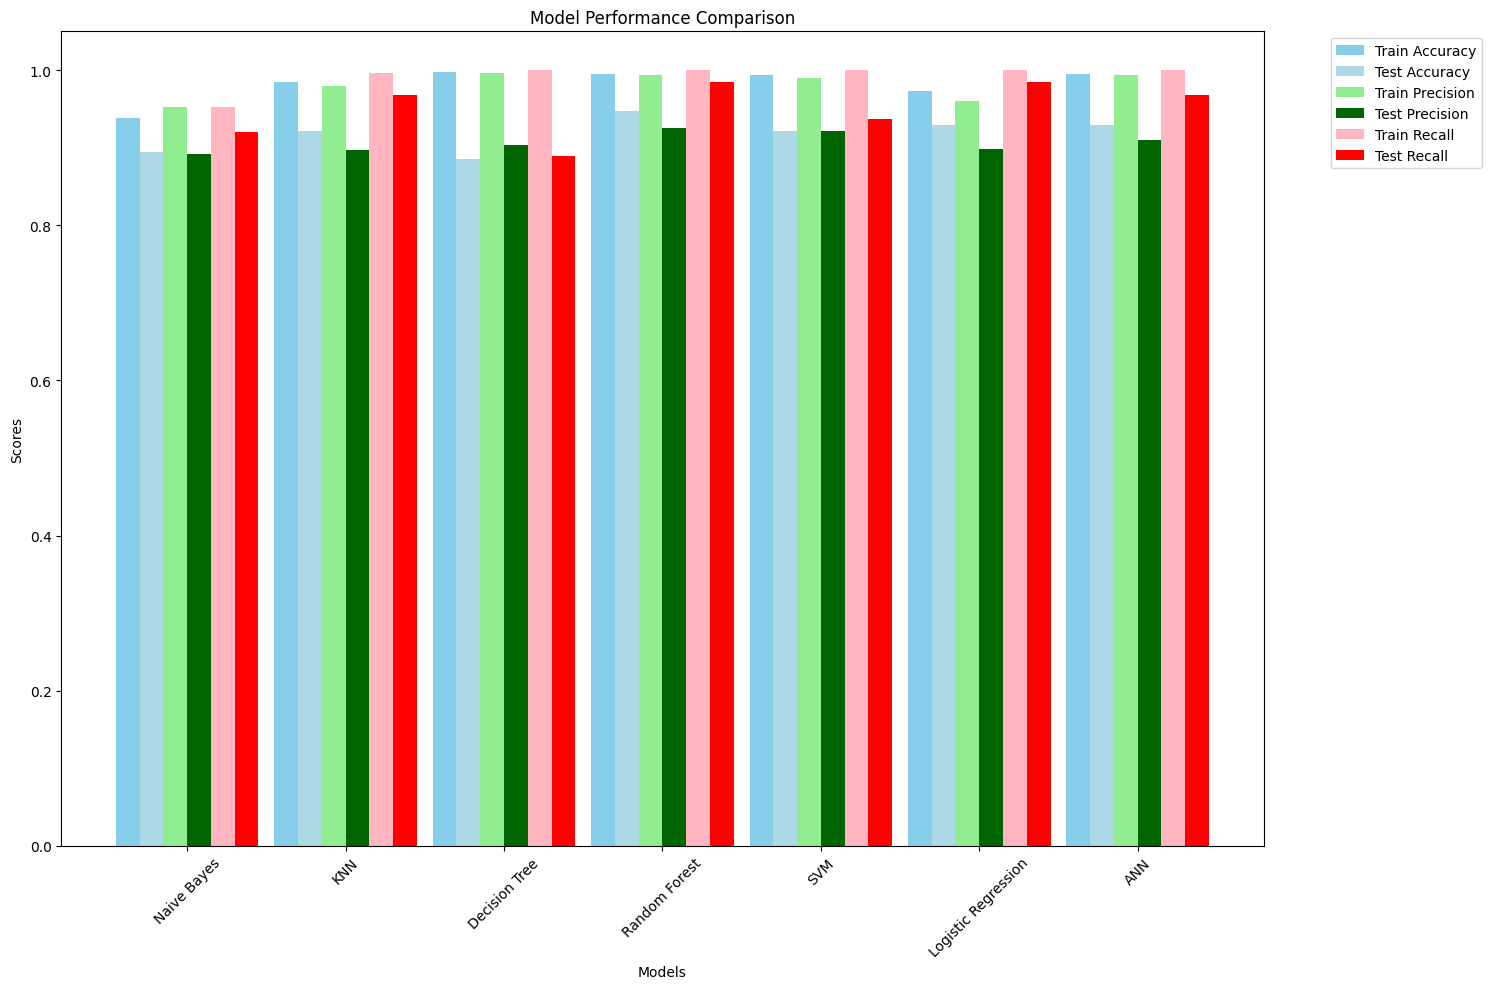

In [90]:
import numpy as np

import matplotlib.pyplot as plt

# Create lists to store performance metrics for each model
models = ['Naive Bayes', 'KNN', 'Decision Tree', 'Random Forest', 'SVM', 'Logistic Regression', 'ANN']
train_accuracy = []
test_accuracy = []
train_precision = []
test_precision = []
train_recall = []
test_recall = []

# Get metrics for each model from the previous results
# Naive Bayes
y_train_pred = gnb.predict(X_train)
y_test_pred = gnb.predict(X_test)
train_accuracy.append(accuracy_score(y_train, gnb.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, gnb.predict(X_test)))
train_precision.append(precision_score(y_train, gnb.predict(X_train)))
test_precision.append(precision_score(y_test, gnb.predict(X_test)))
train_recall.append(recall_score(y_train, gnb.predict(X_train)))
test_recall.append(recall_score(y_test, gnb.predict(X_test)))

# KNN
train_accuracy.append(accuracy_score(y_train, knn.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, knn.predict(X_test)))
train_precision.append(precision_score(y_train, knn.predict(X_train)))
test_precision.append(precision_score(y_test, knn.predict(X_test)))
train_recall.append(recall_score(y_train, knn.predict(X_train)))
test_recall.append(recall_score(y_test, knn.predict(X_test)))

# Decision Tree
train_accuracy.append(accuracy_score(y_train, dt.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, dt.predict(X_test)))
train_precision.append(precision_score(y_train, dt.predict(X_train)))
test_precision.append(precision_score(y_test, dt.predict(X_test)))
train_recall.append(recall_score(y_train, dt.predict(X_train)))
test_recall.append(recall_score(y_test, dt.predict(X_test)))

# Random Forest
train_accuracy.append(accuracy_score(y_train, rf.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, rf.predict(X_test)))
train_precision.append(precision_score(y_train, rf.predict(X_train)))
test_precision.append(precision_score(y_test, rf.predict(X_test)))
train_recall.append(recall_score(y_train, rf.predict(X_train)))
test_recall.append(recall_score(y_test, rf.predict(X_test)))

# SVM
train_accuracy.append(accuracy_score(y_train, svm.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, svm.predict(X_test)))
train_precision.append(precision_score(y_train, svm.predict(X_train)))
test_precision.append(precision_score(y_test, svm.predict(X_test)))
train_recall.append(recall_score(y_train, svm.predict(X_train)))
test_recall.append(recall_score(y_test, svm.predict(X_test)))

# Logistic Regression
train_accuracy.append(accuracy_score(y_train, lr.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, lr.predict(X_test)))
train_precision.append(precision_score(y_train, lr.predict(X_train)))
test_precision.append(precision_score(y_test, lr.predict(X_test)))
train_recall.append(recall_score(y_train, lr.predict(X_train)))
test_recall.append(recall_score(y_test, lr.predict(X_test)))

# ANN
train_accuracy.append(accuracy_score(y_train, ann.predict(X_train)))
test_accuracy.append(accuracy_score(y_test, ann.predict(X_test)))
train_precision.append(precision_score(y_train, ann.predict(X_train)))
test_precision.append(precision_score(y_test, ann.predict(X_test)))
train_recall.append(recall_score(y_train, ann.predict(X_train)))
test_recall.append(recall_score(y_test, ann.predict(X_test)))

# Plotting
plt.figure(figsize=(15, 10))

x = np.arange(len(models))
width = 0.15

plt.bar(x - 2*width, train_accuracy, width, label='Train Accuracy', color='skyblue')
plt.bar(x - width, test_accuracy, width, label='Test Accuracy', color='lightblue')
plt.bar(x, train_precision, width, label='Train Precision', color='lightgreen')
plt.bar(x + width, test_precision, width, label='Test Precision', color='darkgreen')
plt.bar(x + 2*width, train_recall, width, label='Train Recall', color='lightpink')
plt.bar(x + 3*width, test_recall, width, label='Test Recall', color='red')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x + width/2, models, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()